# Cohort Patient Journey — Sepsis vs Normal (Aggregated Means)

Comparing the **average trends** of a cohort of ICU patients who developed sepsis vs those who did not.

We will look at cohorts of size N=50, N=100, and N=500 to see how the patterns stabilize.

## Step 1: Load Cohort & Align Timelines (Max N=200)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load the full dataset to get ALL patients
df_full = pd.read_csv('combined_sepsis_data.csv', low_memory=False)

df_full['SepsisLabel'] = pd.to_numeric(df_full['SepsisLabel'], errors='coerce')
pat_summary = df_full.groupby('Patient_ID')['SepsisLabel'].max().reset_index()

sepsis_ids_all = pat_summary[pat_summary['SepsisLabel'] == 1]['Patient_ID'].values
normal_ids_all = pat_summary[pat_summary['SepsisLabel'] == 0]['Patient_ID'].values

print(f"Loaded full dataset: {len(sepsis_ids_all)} Sepsis patients and {len(normal_ids_all)} Normal patients.")

pt_sep_all = df_full[df_full['Patient_ID'].isin(sepsis_ids_all)].copy()
pt_nor_all = df_full[df_full['Patient_ID'].isin(normal_ids_all)].copy()

# Fast Vectorized rel_hour calculation
pt_sep_all['hour'] = pt_sep_all.groupby('Patient_ID').cumcount()
onset_map = pt_sep_all[pt_sep_all['SepsisLabel'] == 1].groupby('Patient_ID')['hour'].first()
pt_sep_all['rel_hour'] = pt_sep_all['hour'] - pt_sep_all['Patient_ID'].map(onset_map)

pt_sep_all = pt_sep_all.dropna(subset=['rel_hour'])
pt_sep_all['rel_hour'] = pt_sep_all['rel_hour'].astype(int)

pt_nor_all['rel_hour'] = pt_nor_all.groupby('Patient_ID').cumcount() - 12

print("Data aligned successfully.")

Loaded full dataset: 2932 Sepsis patients and 37404 Normal patients.
Data aligned successfully.


## Plot 1: Average Vital Signs Hour-by-Hour (N=50, 100, 500)

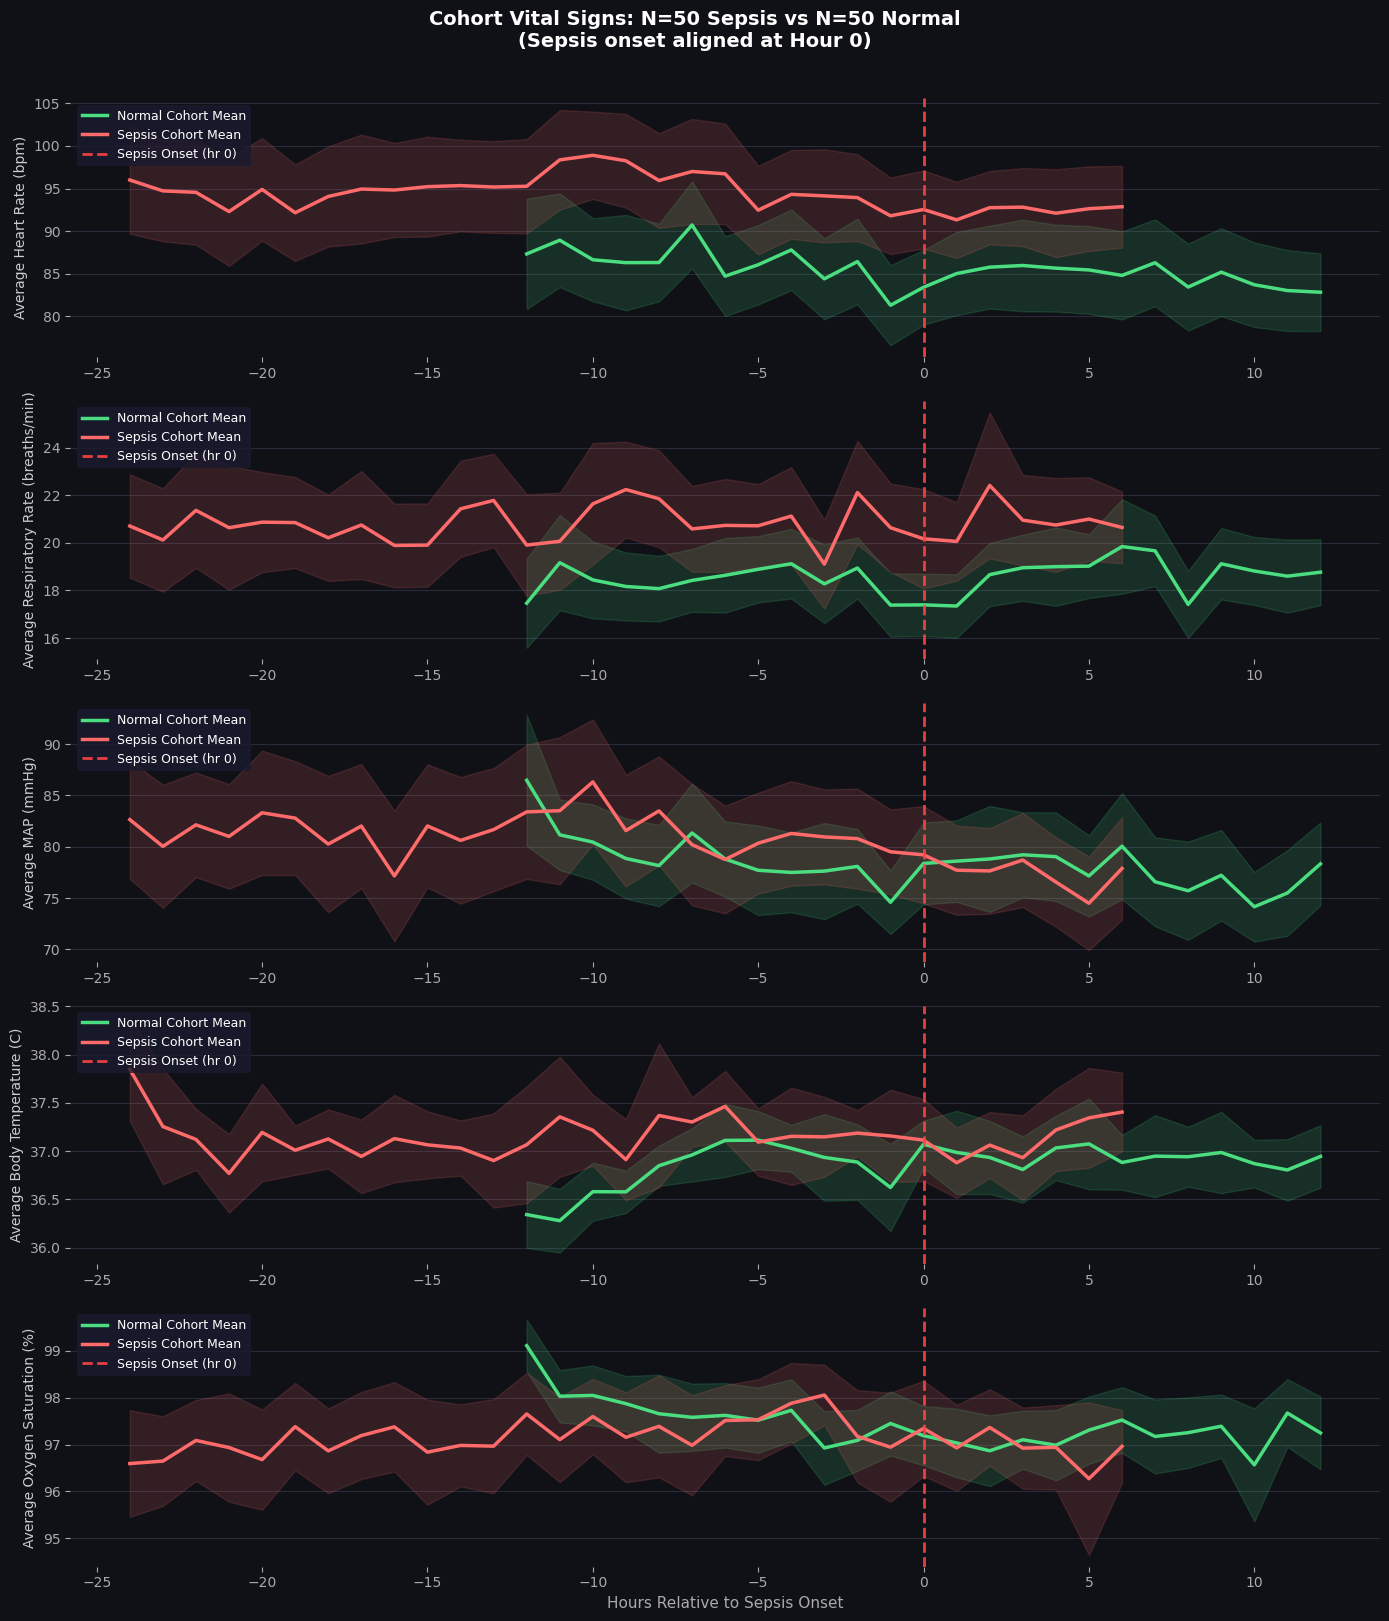

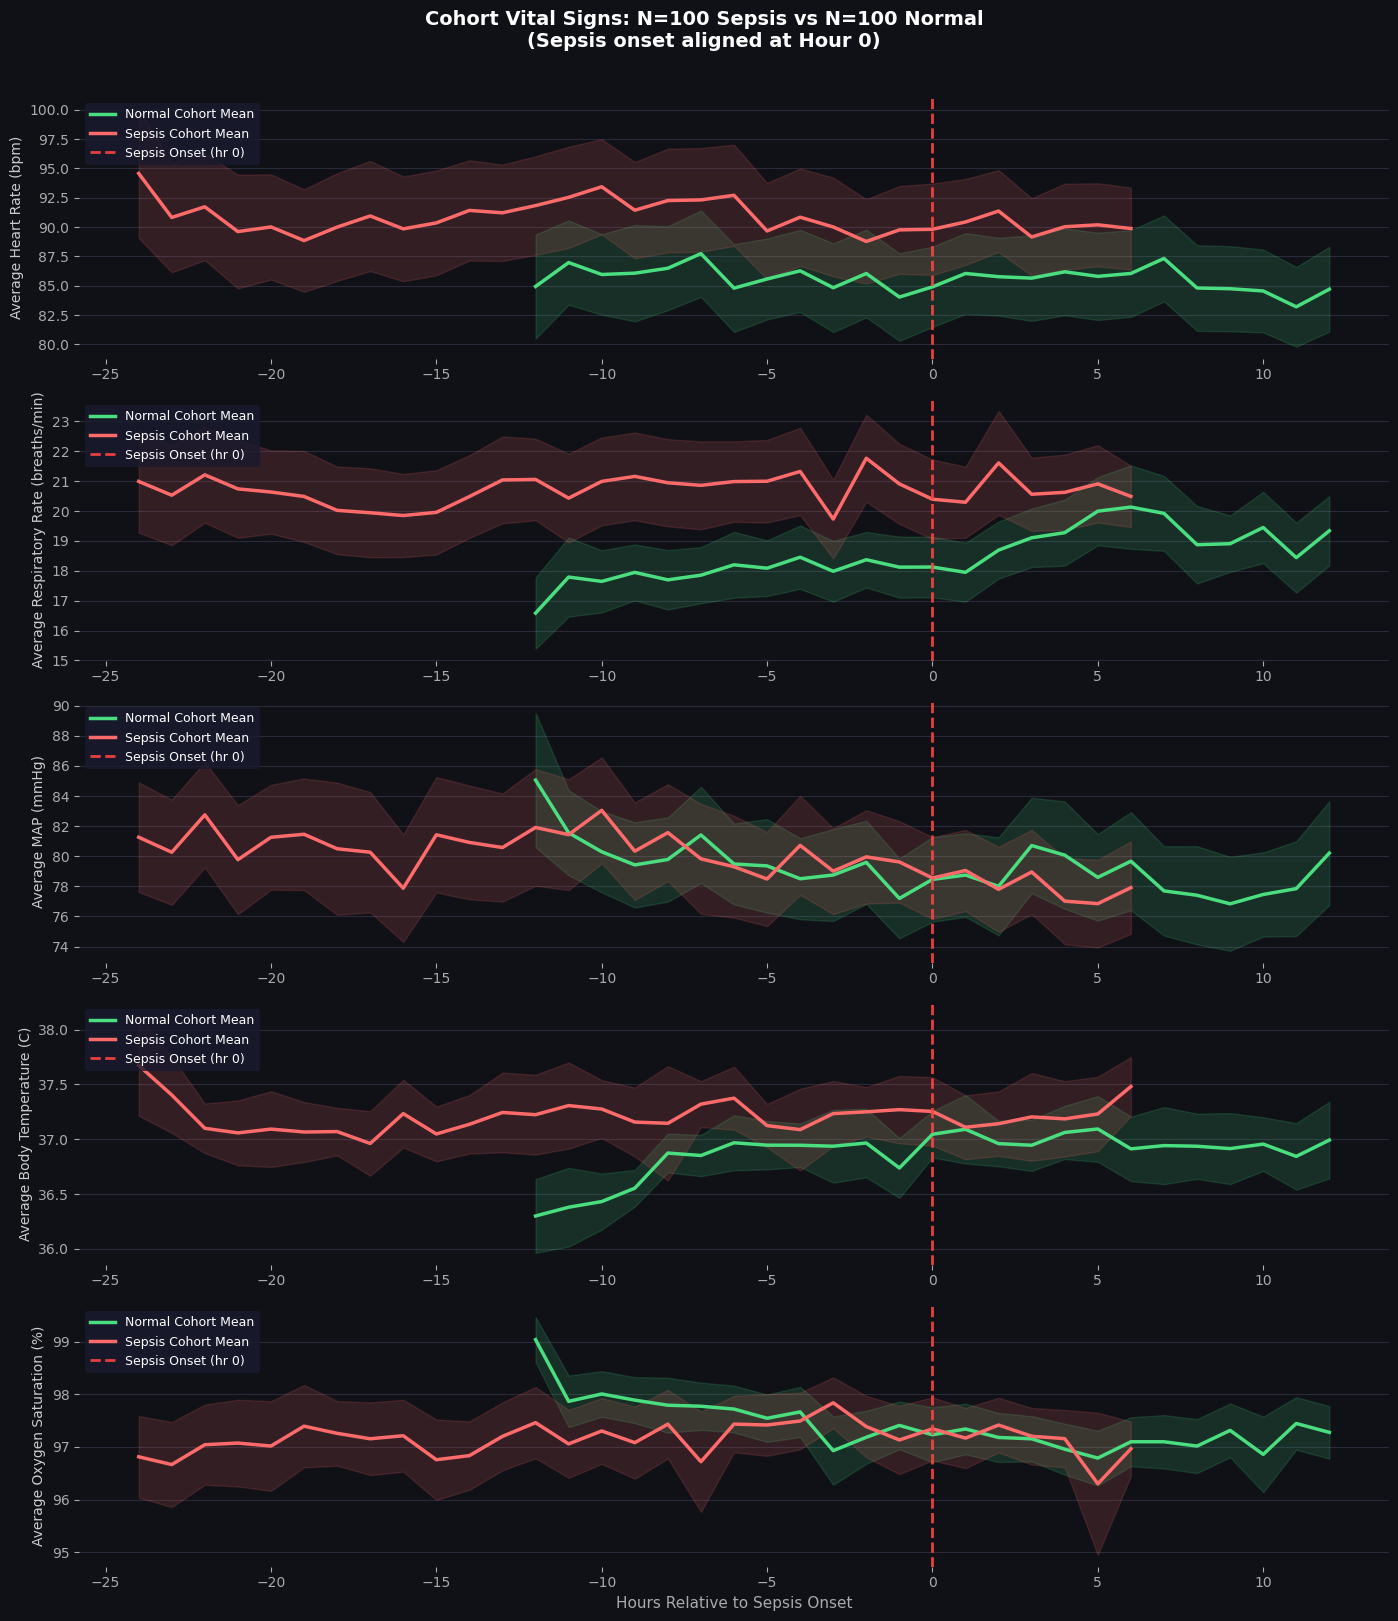

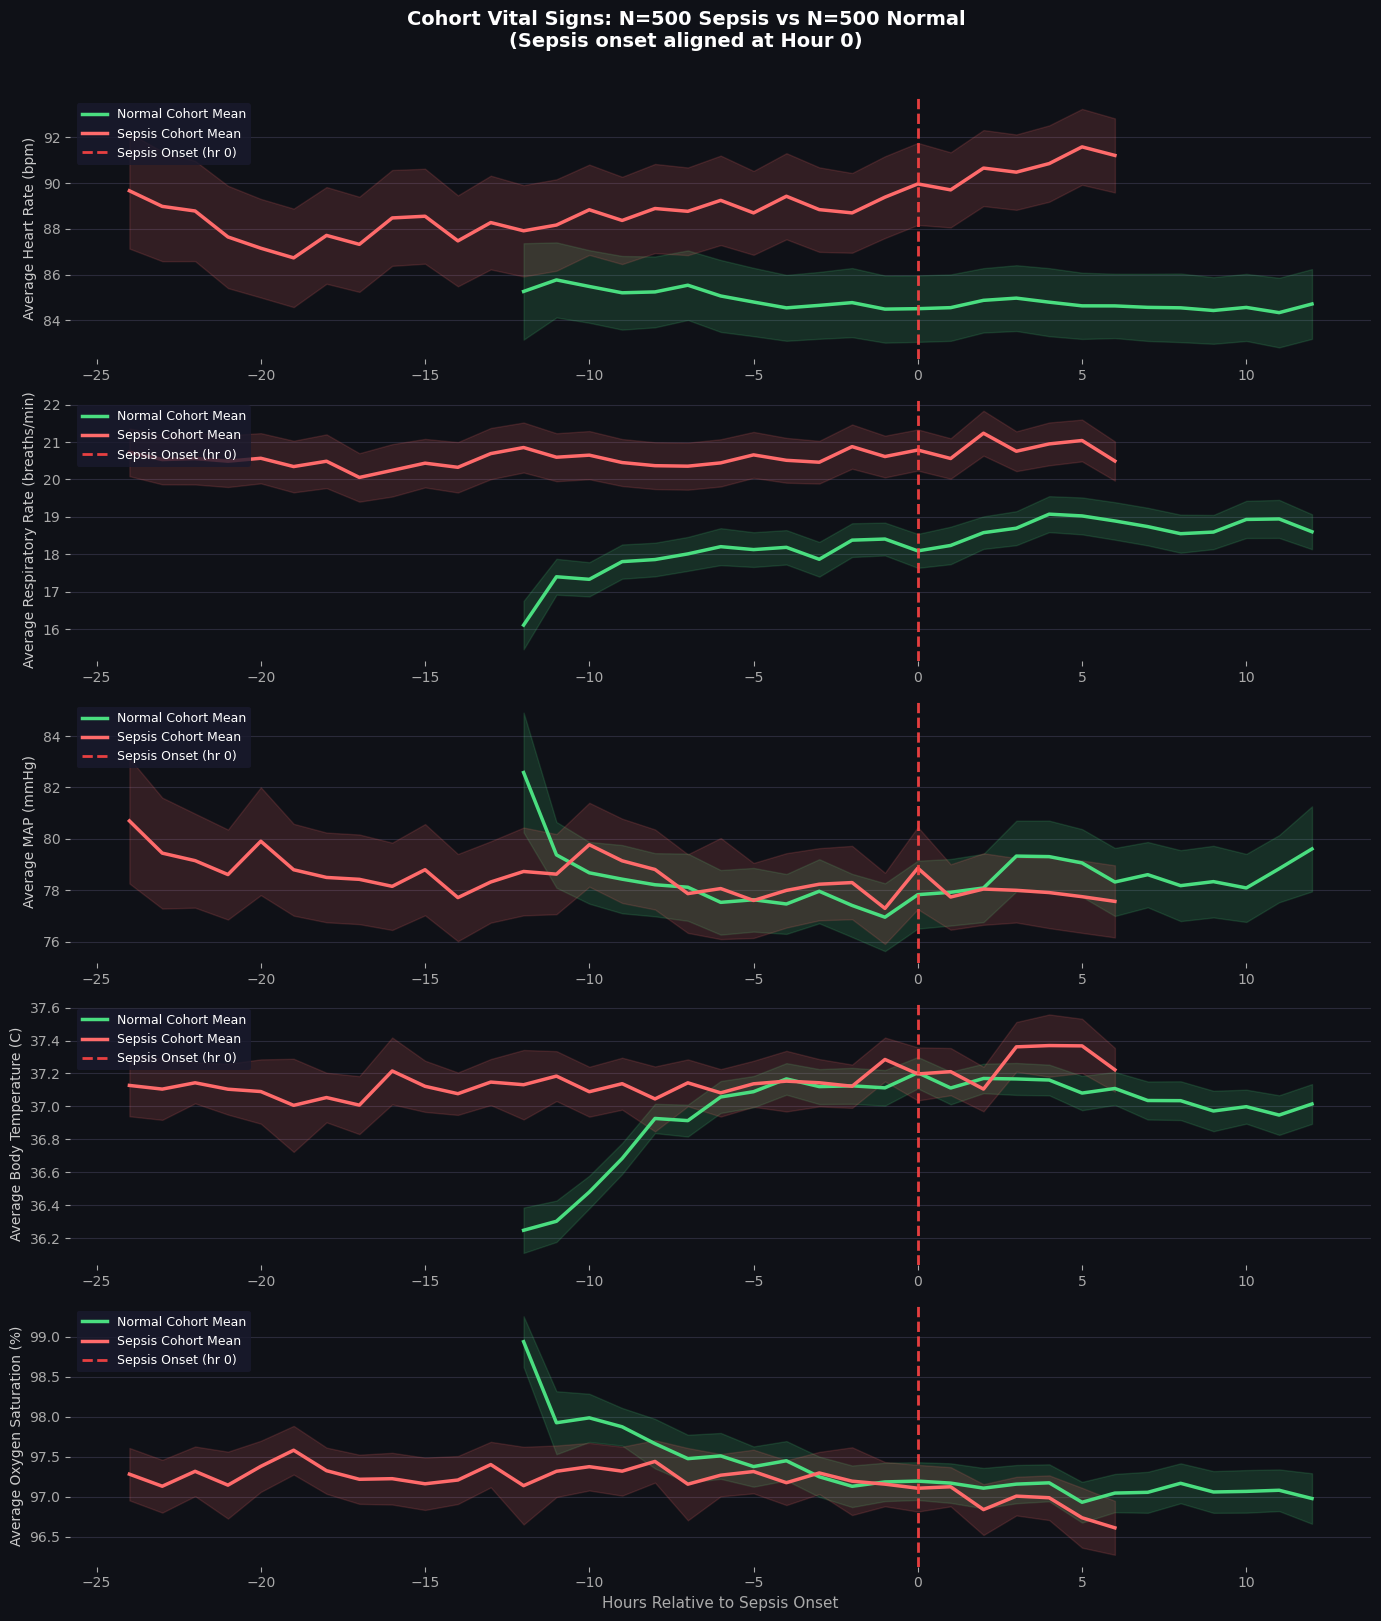

In [3]:
vitals = ['HR', 'Resp', 'MAP', 'Temp', 'O2Sat']
vital_labels = {
    'HR':    'Average Heart Rate (bpm)',
    'Resp':  'Average Respiratory Rate (breaths/min)',
    'MAP':   'Average MAP (mmHg)',
    'Temp':  'Average Body Temperature (C)',
    'O2Sat': 'Average Oxygen Saturation (%)',
}

for v in vitals:
    pt_sep_all[v] = pd.to_numeric(pt_sep_all[v], errors='coerce')
    pt_nor_all[v] = pd.to_numeric(pt_nor_all[v], errors='coerce')

for N in [50, 100, 500]:
    if N > len(sepsis_ids_all):
        break
    
    pt_sep = pt_sep_all[pt_sep_all['Patient_ID'].isin(sepsis_ids_all[:N])]
    pt_nor = pt_nor_all[pt_nor_all['Patient_ID'].isin(normal_ids_all[:N])]
    
    sep_agg = pt_sep[pt_sep['rel_hour'].between(-24, 6)].groupby('rel_hour')[vitals].agg(['mean', 'sem'])
    nor_agg = pt_nor[pt_nor['rel_hour'].between(-24, 12)].groupby('rel_hour')[vitals].agg(['mean', 'sem'])
    
    fig, axes = plt.subplots(len(vitals), 1, figsize=(14, 16))
    fig.patch.set_facecolor('#0F1117')
    fig.suptitle(f'Cohort Vital Signs: N={N} Sepsis vs N={N} Normal\n(Sepsis onset aligned at Hour 0)',
                 color='white', fontsize=14, fontweight='bold', y=1.01)
    
    for ax, v in zip(axes, vitals):
        ax.set_facecolor('#0F1117')
        
        x_nor = nor_agg.index
        y_nor = nor_agg[(v, 'mean')]
        e_nor = nor_agg[(v, 'sem')] * 1.96  
        
        ax.plot(x_nor, y_nor, color='#4ADE80', lw=2.5, label='Normal Cohort Mean', zorder=3)
        ax.fill_between(x_nor, y_nor - e_nor, y_nor + e_nor, color='#4ADE80', alpha=0.15, zorder=2)
        
        x_sep = sep_agg.index
        y_sep = sep_agg[(v, 'mean')]
        e_sep = sep_agg[(v, 'sem')] * 1.96
        
        ax.plot(x_sep, y_sep, color='#FF6B6B', lw=2.5, label='Sepsis Cohort Mean', zorder=3)
        ax.fill_between(x_sep, y_sep - e_sep, y_sep + e_sep, color='#FF6B6B', alpha=0.15, zorder=2)
    
        ax.axvline(0, color='#FF4444', lw=2, ls='--', alpha=0.9, label='Sepsis Onset (hr 0)', zorder=4)
    
        ax.set_ylabel(vital_labels[v], color='#CCCCCC', fontsize=10)
        ax.tick_params(colors='#AAAAAA')
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.yaxis.grid(True, color='#2A2A3A', lw=0.8)
        ax.set_axisbelow(True)
        ax.legend(facecolor='#1A1A2E', edgecolor='none', labelcolor='white', fontsize=9, loc='upper left')
    
    axes[-1].set_xlabel('Hours Relative to Sepsis Onset', color='#AAAAAA', fontsize=11)
    plt.tight_layout()
    plt.show()

## Plot 2: Average Lab Values Over Time (N=50, 100, 500)

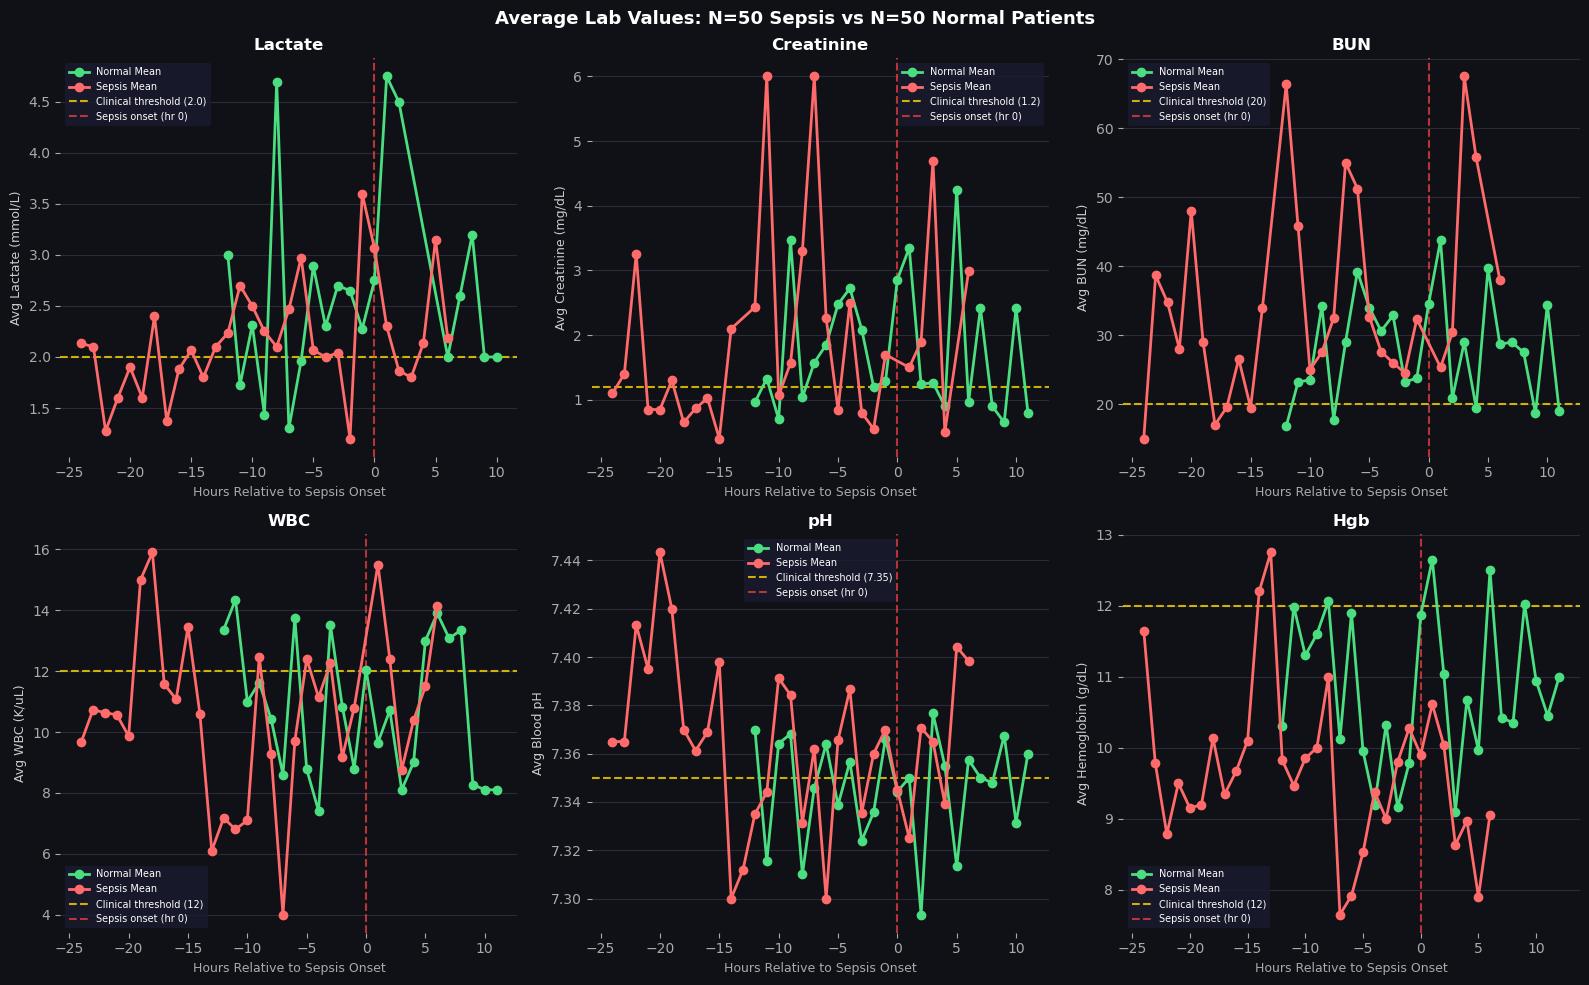

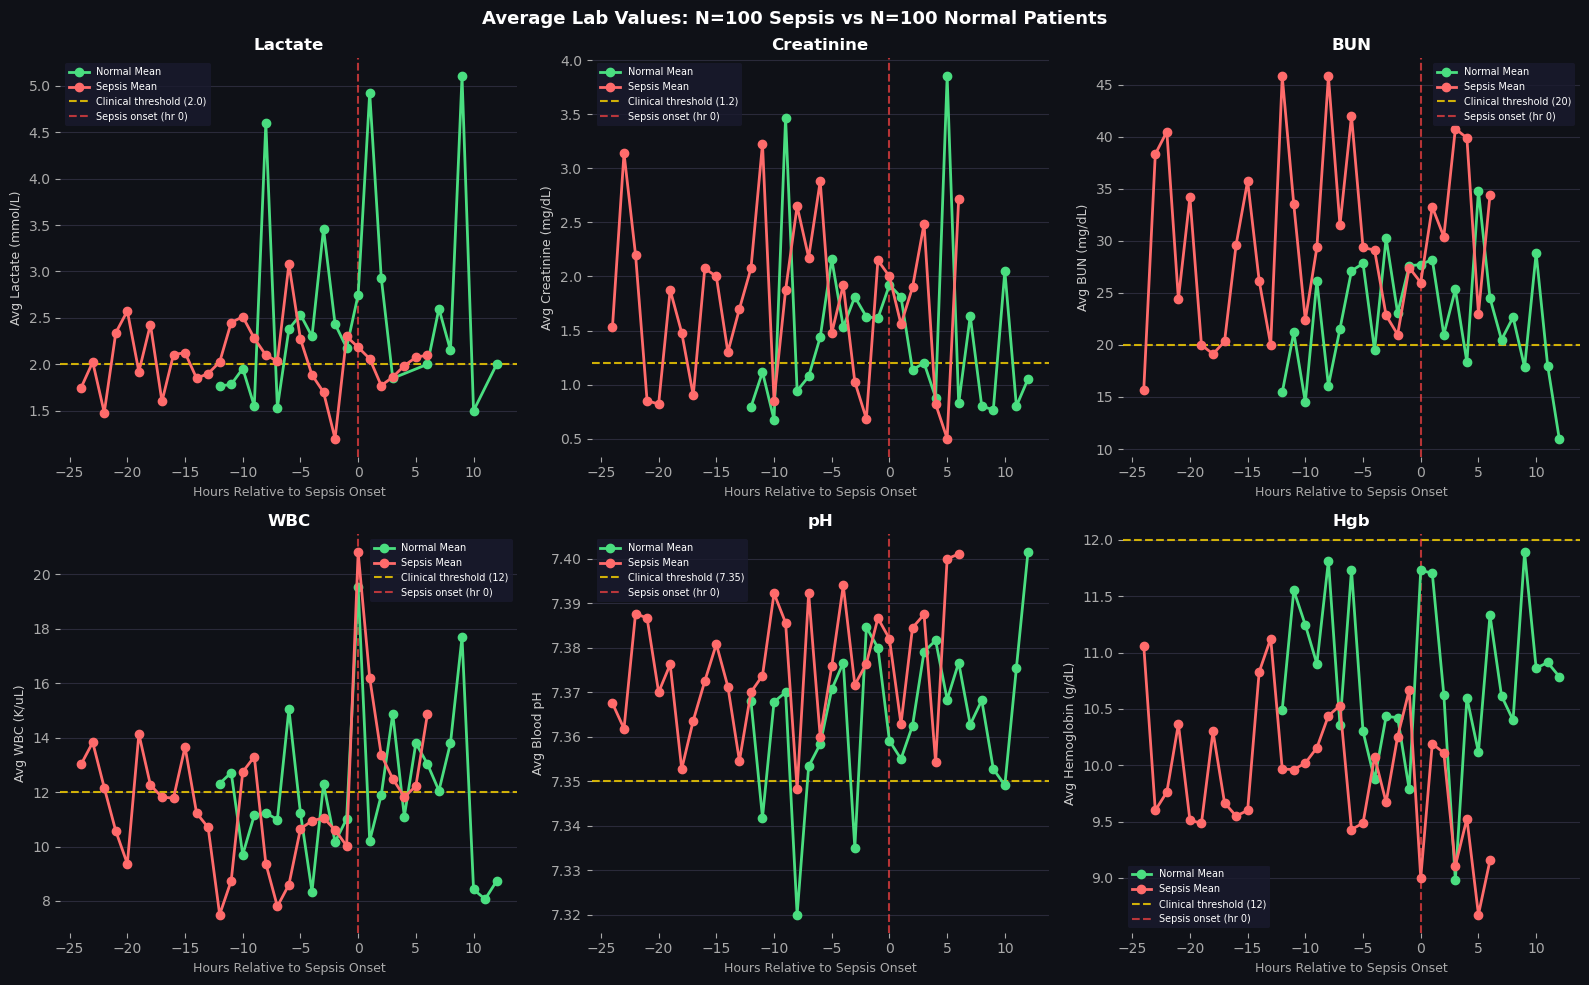

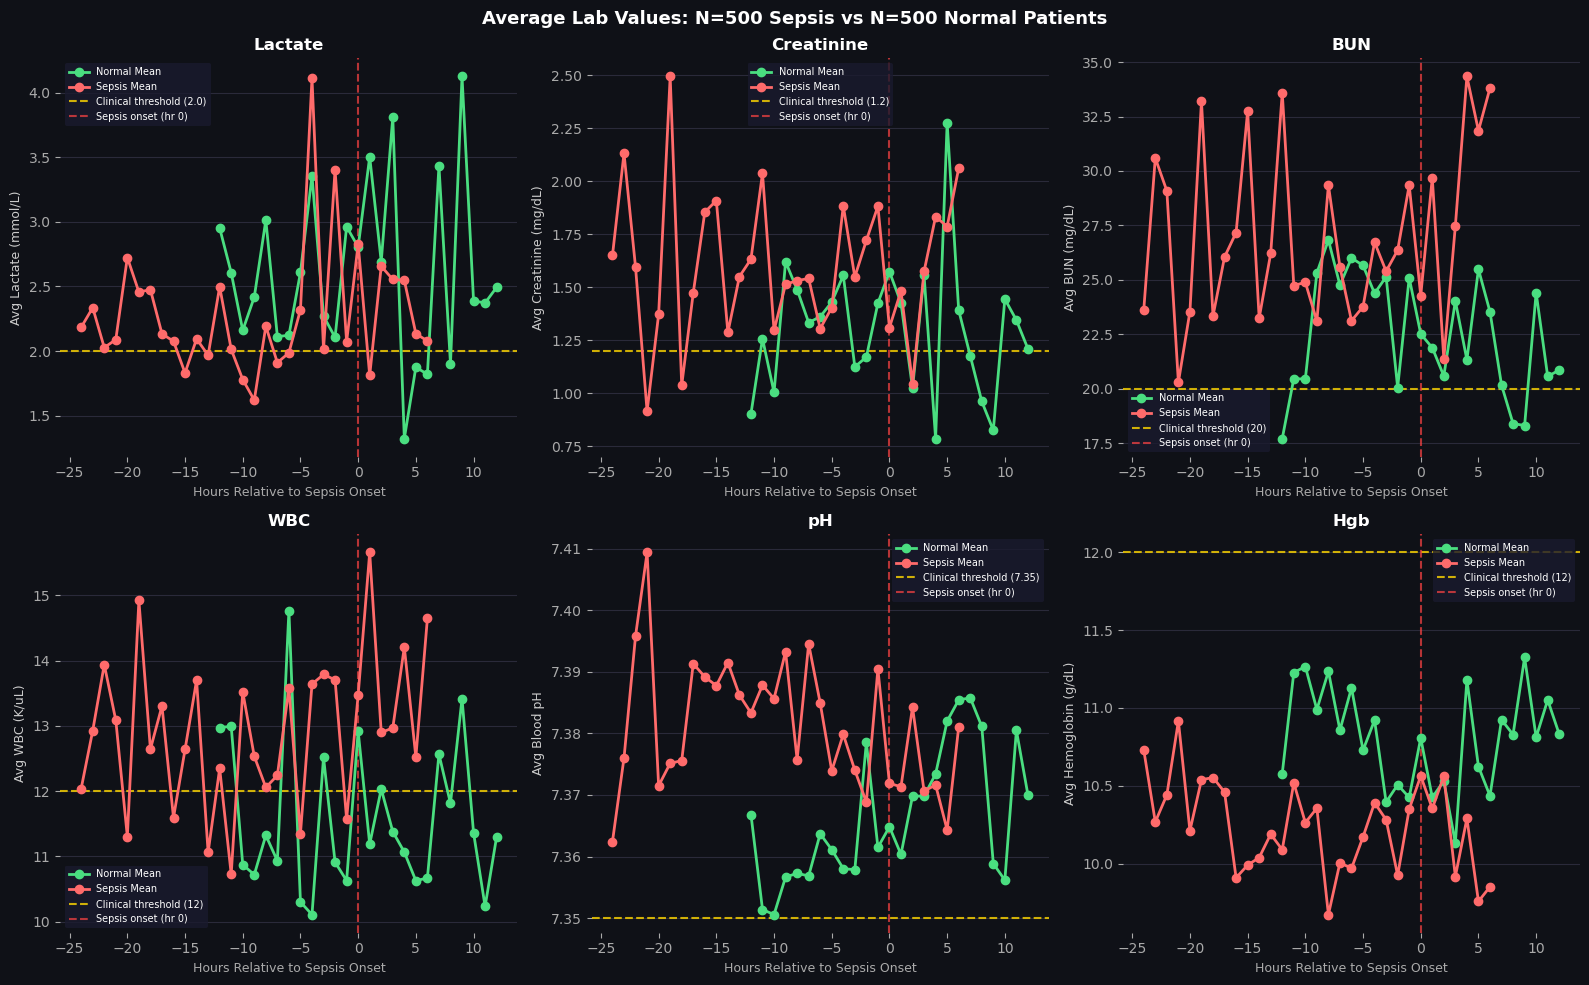

In [4]:
labs = ['Lactate', 'Creatinine', 'BUN', 'WBC', 'pH', 'Hgb']
lab_labels = {
    'Lactate':    'Avg Lactate (mmol/L)',
    'Creatinine': 'Avg Creatinine (mg/dL)',
    'BUN':        'Avg BUN (mg/dL)',
    'WBC':        'Avg WBC (K/uL)',
    'pH':         'Avg Blood pH',
    'Hgb':        'Avg Hemoglobin (g/dL)',
}
thresholds = {
    'Lactate': 2.0, 'Creatinine': 1.2, 'BUN': 20, 
    'WBC': 12, 'pH': 7.35, 'Hgb': 12,
}

for l in labs:
    pt_sep_all[l] = pd.to_numeric(pt_sep_all[l], errors='coerce')
    pt_nor_all[l] = pd.to_numeric(pt_nor_all[l], errors='coerce')

for N in [50, 100, 500]:
    if N > len(sepsis_ids_all):
        break

    pt_sep = pt_sep_all[pt_sep_all['Patient_ID'].isin(sepsis_ids_all[:N])]
    pt_nor = pt_nor_all[pt_nor_all['Patient_ID'].isin(normal_ids_all[:N])]
    
    sep_agg_lab = pt_sep[pt_sep['rel_hour'].between(-24, 6)].groupby('rel_hour')[labs].agg(['mean', 'sem'])
    nor_agg_lab = pt_nor[pt_nor['rel_hour'].between(-24, 12)].groupby('rel_hour')[labs].agg(['mean', 'sem'])
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.patch.set_facecolor('#0F1117')
    fig.suptitle(f'Average Lab Values: N={N} Sepsis vs N={N} Normal Patients',
                 color='white', fontsize=13, fontweight='bold')
    
    for ax, lab in zip(axes.flatten(), labs):
        ax.set_facecolor('#0F1117')
        
        y_nor = nor_agg_lab[(lab, 'mean')].dropna()
        x_nor = y_nor.index
        ax.plot(x_nor, y_nor, 'o-', color='#4ADE80', lw=2, ms=6, label='Normal Mean', zorder=3)
        
        y_sep = sep_agg_lab[(lab, 'mean')].dropna()
        x_sep = y_sep.index
        ax.plot(x_sep, y_sep, 'o-', color='#FF6B6B', lw=2, ms=6, label='Sepsis Mean', zorder=3)
    
        if lab in thresholds:
            thresh = thresholds[lab]
            ax.axhline(thresh, color='#FFD700', lw=1.5, ls='--', alpha=0.8, label=f'Clinical threshold ({thresh})')
    
        ax.axvline(0, color='#FF4444', lw=1.5, ls='--', alpha=0.7, label='Sepsis onset (hr 0)')
    
        ax.set_title(lab, color='white', fontweight='bold')
        ax.set_ylabel(lab_labels[lab], color='#CCCCCC', fontsize=9)
        ax.set_xlabel('Hours Relative to Sepsis Onset', color='#AAAAAA', fontsize=9)
        ax.tick_params(colors='#AAAAAA')
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.yaxis.grid(True, color='#2A2A3A', lw=0.8)
        ax.set_axisbelow(True)
        ax.legend(facecolor='#1A1A2E', edgecolor='none', labelcolor='white', fontsize=7, loc='best')
    
    plt.tight_layout()
    plt.show()

## Plot 3: The Power of 'Missing Data' (Informative Missingness)\n\nDoctors only order painful or expensive lab tests (like Lactate) when they suspect something is wrong. Here we see how the **average number of tests ordered per day** is significantly higher for Sepsis patients.

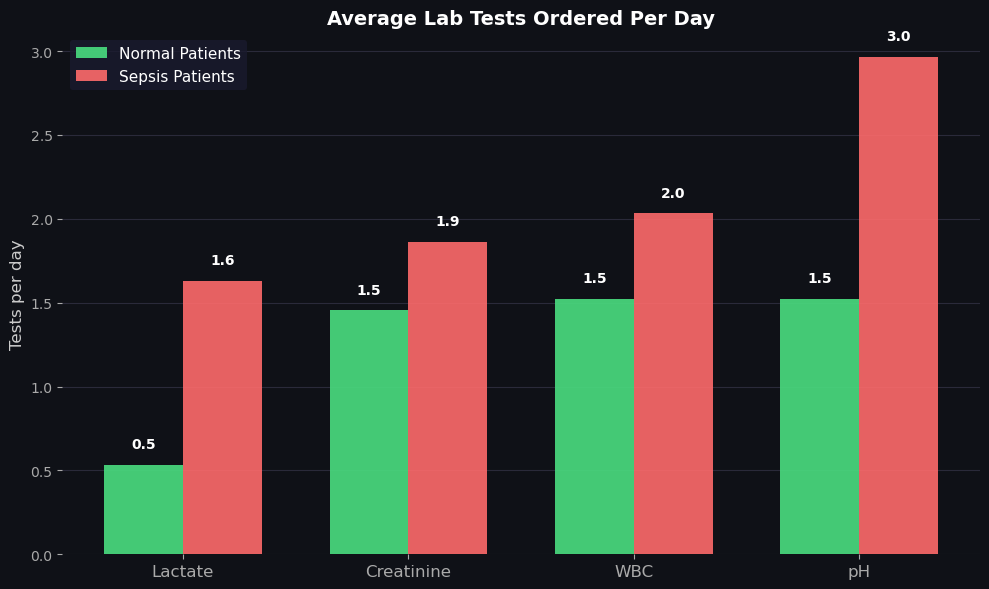

In [5]:
focus_labs = ['Lactate', 'Creatinine', 'WBC', 'pH']
sep_tests_per_day = {}
nor_tests_per_day = {}

for lab in focus_labs:
    # Count tests per patient, divide by their stay duration in days (hours/24)
    sep_counts = pt_sep_all.groupby('Patient_ID')[lab].count()
    sep_days = pt_sep_all.groupby('Patient_ID').size() / 24.0
    sep_tests_per_day[lab] = (sep_counts / sep_days).mean()
    
    nor_counts = pt_nor_all.groupby('Patient_ID')[lab].count()
    nor_days = pt_nor_all.groupby('Patient_ID').size() / 24.0
    nor_tests_per_day[lab] = (nor_counts / nor_days).mean()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

x = np.arange(len(focus_labs))
width = 0.35

ax.bar(x - width/2, [nor_tests_per_day[l] for l in focus_labs], width, label='Normal Patients', color='#4ADE80', alpha=0.9)
ax.bar(x + width/2, [sep_tests_per_day[l] for l in focus_labs], width, label='Sepsis Patients', color='#FF6B6B', alpha=0.9)

for i, lab in enumerate(focus_labs):
    ax.text(i - width/2, nor_tests_per_day[lab] + 0.1, f"{nor_tests_per_day[lab]:.1f}", ha='center', color='white', fontweight='bold')
    ax.text(i + width/2, sep_tests_per_day[lab] + 0.1, f"{sep_tests_per_day[lab]:.1f}", ha='center', color='white', fontweight='bold')

ax.set_title('Average Lab Tests Ordered Per Day', color='white', fontweight='bold', fontsize=14)
ax.set_ylabel('Tests per day', color='#CCCCCC', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(focus_labs, color='white', fontsize=12)
ax.tick_params(colors='#AAAAAA')

for spine in ax.spines.values(): spine.set_visible(False)
ax.yaxis.grid(True, color='#2A2A3A', lw=0.8)
ax.set_axisbelow(True)
ax.legend(facecolor='#1A1A2E', edgecolor='none', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.show()

## Plot 4: When does Sepsis usually strike?\n\nA distribution showing the hour of ICU admission when Sepsis is officially diagnosed.

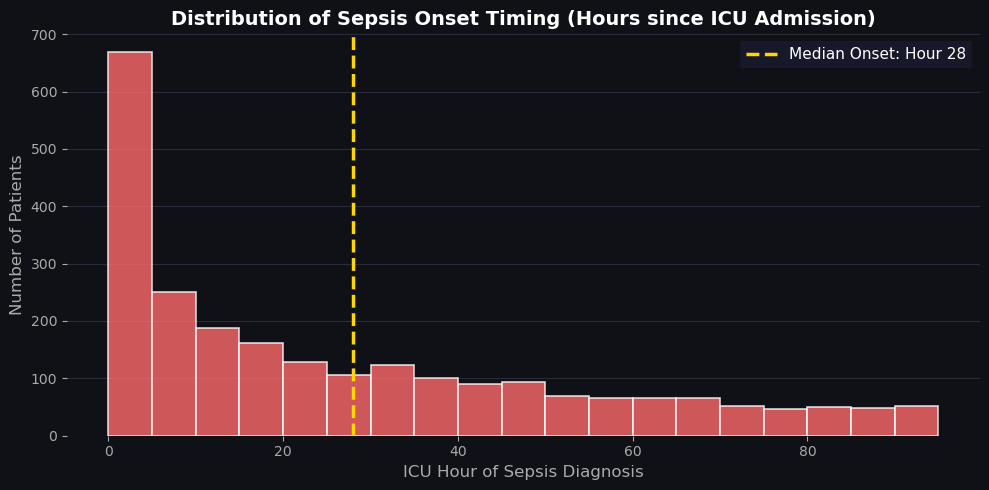

In [6]:
# We need the absolute onset hour (ICU hour) for all sepsis patients
# We can do this instantly using vectorized pandas operations instead of a slow loop
pt_sep_all['hour'] = pt_sep_all.groupby('Patient_ID').cumcount()
onset_hours = pt_sep_all[pt_sep_all['SepsisLabel'] == 1].groupby('Patient_ID')['hour'].first().values

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

bins = range(0, 100, 5)
ax.hist(onset_hours, bins=bins, color='#FF6B6B', alpha=0.8, edgecolor='white', linewidth=1.2)

median_onset = np.median(onset_hours)
ax.axvline(median_onset, color='#FFD700', lw=2.5, ls='--', label=f'Median Onset: Hour {median_onset:.0f}')

ax.set_title('Distribution of Sepsis Onset Timing (Hours since ICU Admission)', color='white', fontweight='bold', fontsize=14)
ax.set_xlabel('ICU Hour of Sepsis Diagnosis', color='#AAAAAA', fontsize=12)
ax.set_ylabel('Number of Patients', color='#AAAAAA', fontsize=12)
ax.tick_params(colors='#AAAAAA')

for spine in ax.spines.values(): spine.set_visible(False)
ax.yaxis.grid(True, color='#2A2A3A', lw=0.8)
ax.set_axisbelow(True)
ax.legend(facecolor='#1A1A2E', edgecolor='none', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.show()